In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple

class TransformerSelfAttention:
    """
    Implementation of the self-attention mechanism used in Transformer encoders.
    """
    def __init__(self, d_model: int, num_heads: int = 8, seed: int = 42):
        """
        Initialize the self-attention module.

        Args:
            d_model: Embedding dimension
            num_heads: Number of attention heads
            seed: Random seed for reproducibility
        """
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Set random seed for reproducibility
        np.random.seed(seed)

        # Initialize weight matrices
        self.W_q = np.random.randn(d_model, d_model) * 0.1
        self.W_k = np.random.randn(d_model, d_model) * 0.1
        self.W_v = np.random.randn(d_model, d_model) * 0.1
        self.W_o = np.random.randn(d_model, d_model) * 0.1

    def scaled_dot_product_attention(self, Q: np.ndarray, K: np.ndarray, V: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Compute scaled dot-product attention.

        Args:
            Q: Query matrix [seq_len, d_k]
            K: Key matrix [seq_len, d_k]
            V: Value matrix [seq_len, d_v]

        Returns:
            output: Weighted sum based on attention scores
            attention_weights: Softmax-normalized attention weights
        """
        # Compute attention scores
        scores = np.matmul(Q, K.T)

        # Scale scores
        d_k = K.shape[1]
        scores = scores / np.sqrt(d_k)

        # Apply softmax to get attention weights
        attention_weights = self.softmax(scores)

        # Apply attention weights to values
        output = np.matmul(attention_weights, V)

        return output, attention_weights

    def softmax(self, x: np.ndarray) -> np.ndarray:
        """
        Numerically stable softmax implementation.

        Args:
            x: Input tensor

        Returns:
            Softmax-normalized tensor
        """
        # Subtract max for numerical stability
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

    def forward(self, embeddings: np.ndarray) -> Tuple[np.ndarray, List[np.ndarray]]:
        """
        Forward pass of the self-attention layer.

        Args:
            embeddings: Token embeddings [seq_len, d_model]

        Returns:
            output: Self-attention layer output
            all_attentions: List of attention weights for each head
        """
        seq_len = embeddings.shape[0]

        # Single head attention for demonstration
        Q = np.matmul(embeddings, self.W_q)
        K = np.matmul(embeddings, self.W_k)
        V = np.matmul(embeddings, self.W_v)

        single_output, single_attention = self.scaled_dot_product_attention(Q, K, V)

        # Multi-head attention
        all_head_outputs = []
        all_attentions = []

        for h in range(self.num_heads):
            # Weight matrices for this head
            W_q_h = self.W_q[:, h * self.head_dim:(h + 1) * self.head_dim]
            W_k_h = self.W_k[:, h * self.head_dim:(h + 1) * self.head_dim]
            W_v_h = self.W_v[:, h * self.head_dim:(h + 1) * self.head_dim]

            # Linear projections
            Q_h = np.matmul(embeddings, W_q_h)
            K_h = np.matmul(embeddings, W_k_h)
            V_h = np.matmul(embeddings, W_v_h)

            # Compute attention
            head_output, head_attention = self.scaled_dot_product_attention(Q_h, K_h, V_h)

            all_head_outputs.append(head_output)
            all_attentions.append(head_attention)

        # Concatenate all head outputs
        concat_output = np.concatenate(all_head_outputs, axis=1)

        # Final projection
        output = np.matmul(concat_output, self.W_o)

        return output, all_attentions, single_attention




In [3]:
def analyze_token_relationships(tokens: List[str], attention_weights: np.ndarray, top_k: int = 3) -> None:
    """
    Analyze and print the strongest token relationships based on attention weights.

    Args:
        tokens: List of tokens
        attention_weights: Attention weights
        top_k: Number of top relationships to show
    """
    print("\n===== Token Relationship Analysis =====")
    for i, token in enumerate(tokens):
        # Get the tokens this token attends to most strongly
        token_attentions = attention_weights[i]
        top_indices = np.argsort(token_attentions)[-top_k:][::-1]

        relationships = []
        for idx in top_indices:
            relationships.append(f"{tokens[idx]} ({token_attentions[idx]:.4f})")

        print(f"{token} → {', '.join(relationships)}")




In [4]:

def visualize_attention(tokens: List[str], attention_weights: np.ndarray, title: str = "Self-Attention Weights",
                        filename: str = "attention_weights.png") -> None:
    """
    Visualize attention weights as a heatmap.

    Args:
        tokens: List of tokens
        attention_weights: Attention weights
        title: Plot title
        filename: Output filename
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_weights, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=tokens, yticklabels=tokens)
    plt.title(title)
    plt.xlabel("Key Tokens")
    plt.ylabel("Query Tokens")
    plt.tight_layout()
    plt.savefig(filename)
    print(f"Visualization saved as '{filename}'")


def visualize_multihead_attention(tokens: List[str], all_attentions: List[np.ndarray],
                                 filename: str = "multihead_attention.png") -> None:
    """
    Visualize attention weights for multiple heads.

    Args:
        tokens: List of tokens
        all_attentions: List of attention weight matrices
        filename: Output filename
    """
    num_heads = len(all_attentions)
    fig_cols = min(3, num_heads)
    fig_rows = (num_heads + fig_cols - 1) // fig_cols

    plt.figure(figsize=(5 * fig_cols, 4 * fig_rows))

    for h, attention in enumerate(all_attentions):
        plt.subplot(fig_rows, fig_cols, h + 1)
        sns.heatmap(attention, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=tokens, yticklabels=tokens)
        plt.title(f"Attention Head {h + 1}")
        plt.tight_layout()

    plt.savefig(filename)
    print(f"Multi-head visualization saved as '{filename}'")



Self-Attention in Transformer Encoder
Input sentence: ['what', 'are', 'the', 'symptoms', 'of', 'diabetes', '?']
Embeddings shape: (7, 16)
Output shape: (7, 16)

===== Single-Head Attention =====
Attention scores (before softmax):
[[ 1.57532584e-03 -2.02121422e-03 -7.96134080e-04  5.39481776e-04
   3.06174474e-03  9.68375973e-04 -1.66493247e-03]
 [-2.84659641e-03  8.52532529e-04 -1.99005760e-03 -5.34956957e-04
  -2.50585354e-03  2.62476835e-05 -1.64060630e-04]
 [-5.28577548e-04  1.72012624e-03 -1.10402640e-03 -1.11560576e-03
   1.24872573e-04 -1.23170477e-03 -1.05459144e-04]
 [ 5.19218004e-04 -1.13554740e-03 -2.97887602e-04 -4.02582017e-04
   2.70753796e-03 -2.80297752e-05 -3.38555386e-04]
 [ 4.10817921e-04 -5.56333468e-04  7.55851845e-04 -1.28330086e-03
   2.20701104e-03  1.77058490e-04 -1.15583260e-03]
 [-6.07971545e-04 -3.85061644e-05 -2.06840359e-04 -1.02870840e-03
   2.17662477e-03 -2.98567125e-04 -1.30289705e-03]
 [-8.44943197e-04  8.82876826e-04 -1.45105358e-03 -5.55941162e-04
  

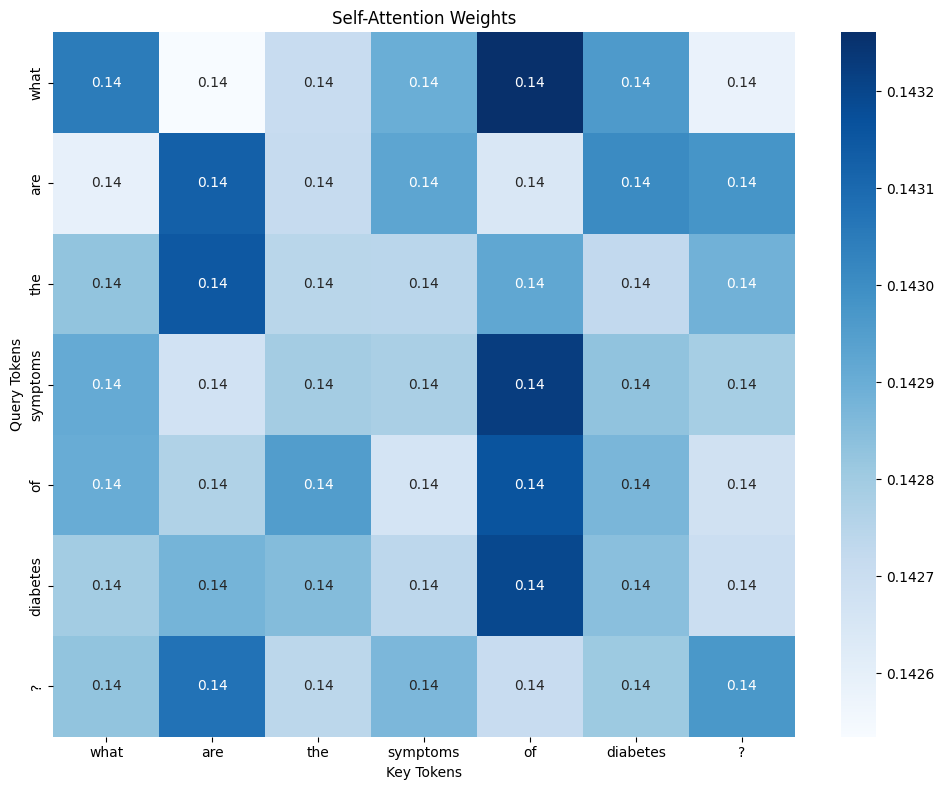

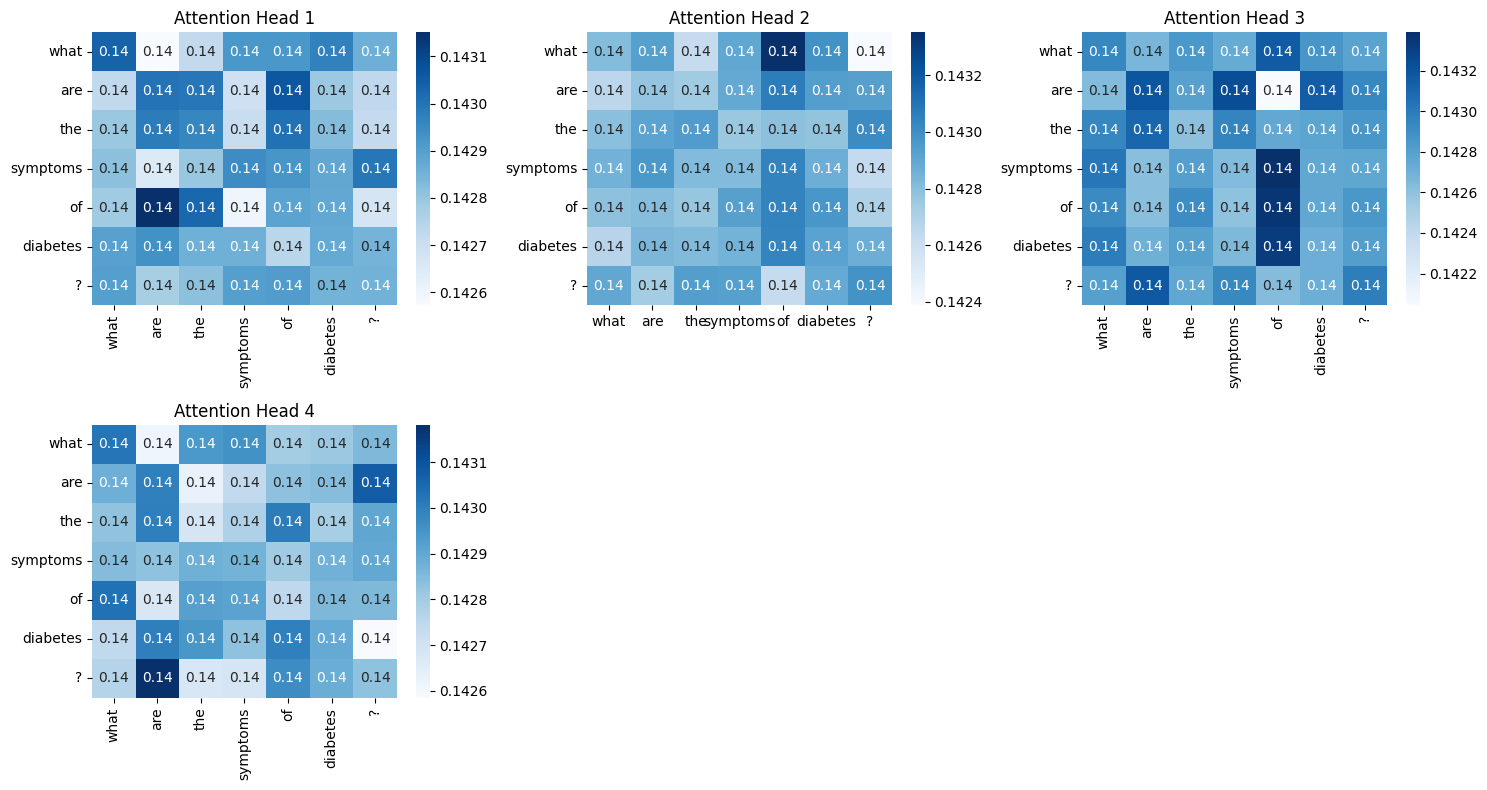

In [5]:
def main():
    # Define the input sentence about diabetes
    sentence = ["what", "are", "the", "symptoms", "of", "diabetes", "?"]
    seq_length = len(sentence)

    # Parameters
    d_model = 16  # Small embedding dimension for clarity
    num_heads = 4  # Number of attention heads

    # Create mock embeddings
    np.random.seed(42)
    embeddings = np.random.randn(seq_length, d_model) * 0.1

    # Create self-attention layer
    self_attention = TransformerSelfAttention(d_model=d_model, num_heads=num_heads)

    # Forward pass
    output, all_attentions, single_attention = self_attention.forward(embeddings)

    # Display results
    print("=" * 50)
    print("Self-Attention in Transformer Encoder")
    print("=" * 50)
    print(f"Input sentence: {sentence}")
    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Output shape: {output.shape}")

    print("\n===== Single-Head Attention =====")
    print("Attention scores (before softmax):")
    Q = np.matmul(embeddings, self_attention.W_q)
    K = np.matmul(embeddings, self_attention.W_k)
    scores = np.matmul(Q, K.T) / np.sqrt(d_model)
    print(scores)

    print("\nAttention weights (after softmax):")
    print(single_attention)

    # Analyze token relationships
    analyze_token_relationships(sentence, single_attention)

    # Visualize attention weights
    visualize_attention(sentence, single_attention)

    # Visualize multi-head attention
    visualize_multihead_attention(sentence, all_attentions)

    # Calculate and display contextual token representations
    print("\n===== Contextual Token Representations =====")
    for i, token in enumerate(sentence):
        print(f"{token}: {output[i][:5]}...")  # Show first 5 values


if __name__ == "__main__":
    main()